In [24]:
import glob as glob
import json
import matplotlib.pyplot as plt


In [29]:
# 1. Load data
foldername = "../adv_data/norm-pgd_max-iter-5/*"
filenames = glob.glob(foldername)

filenames

['../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.21.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.01.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.17.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.16.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.07.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.11.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.27.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.26.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.06.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.1.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.13.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.05.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.29.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.2.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.09.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.25.json',
 '../adv_data/norm-pgd_max-iter-5/adv_test_eps_0.24.json',

## Displaying F1 Score vs. Epsilon

In [30]:
x, y= [], []

for filename in filenames:
    with open(filename, 'r') as file:
        data = json.load(file)
        if not 'eps' in data.keys(): 
            continue
        x.append(data['eps'])
        y.append(data['f1'])

x, y

([0.21,
  0.01,
  0.17,
  0.16,
  0.07,
  0.11,
  0.27,
  0.26,
  0.06,
  0.1,
  0.13,
  0.05,
  0.29,
  0.2,
  0.09,
  0.25,
  0.24,
  0.08,
  0.3,
  0.28,
  0.04,
  0.12,
  0.19,
  0.23,
  0.15,
  0.03,
  0.02,
  0.14,
  0.22,
  0.18],
 [0.35673437706425165,
  0.9922035425317566,
  0.3917497910223434,
  0.4014342748301729,
  0.6290417791684256,
  0.3952879050119963,
  0.3598275161732238,
  0.3592394319572113,
  0.7268324136710413,
  0.3945587267522029,
  0.39864474400507177,
  0.8046156925054246,
  0.3592692494972003,
  0.3571710130738823,
  0.4340509067137071,
  0.3582661758838381,
  0.35737456344961027,
  0.5142888661493786,
  0.3593953494013138,
  0.3599784866219115,
  0.8712023594200746,
  0.39558147639846925,
  0.3691345115170637,
  0.35760155898631163,
  0.4065857139577888,
  0.9271550075938886,
  0.9910070601096137,
  0.40461154434540225,
  0.35703965399591,
  0.3811596589586656])

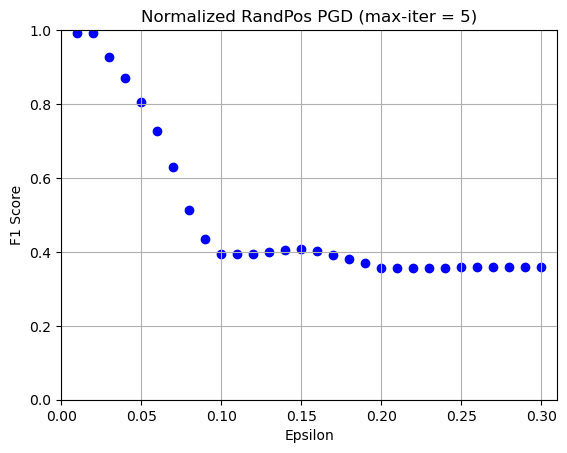

In [32]:
# For adv_test - plot F1 score vs. epsilon
# 2. Create the line plot
plt.scatter(x, y, color='blue', marker="o")

# 3. Add titles and labels
plt.title("Normalized RandPos PGD (max-iter = 5)")
plt.xlabel("Epsilon")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xlim(0, 0.31)
plt.grid(True)

# 4. Display the graph

## Displaying F1 Score vs. Run type

In [22]:
cat_vals = {}
for filename in filenames:
    with open(filename, 'r') as file:
        data = json.load(file)
        norm_type = "Denorm" if "denorm" in filename else "Norm"
        
        # Loop through each run and average the results
        for run in (data["benign"]):
            wrapper_type = "Wrapper" if run["wrapper"] else "Og"
            key = f"{norm_type}-{wrapper_type}"

            if not key in cat_vals.keys():
                cat_vals[key] = []

            cat_vals[key].append(run["f1"])


cat_vals

{'Denorm-Wrapper': [0.9829195656898114],
 'Denorm-Og': [0.9714426699563232],
 'Norm-Wrapper': [0.9917344098986437],
 'Norm-Og': [0.9860291034334886, 0.9860291034334886]}

dict_keys(['Denorm-Wrapper', 'Denorm-Og', 'Norm-Wrapper', 'Norm-Og']) dict_values([0.9829195656898114, 0.9714426699563232, 0.9917344098986437, 0.9860291034334886])


Text(0.5, 1.0, 'F1 Score vs. Run Type')

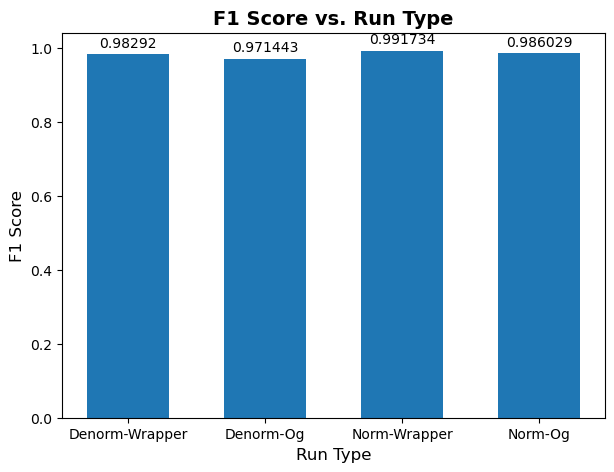

In [20]:
cats = cat_vals.keys()
vals = cat_vals.values()
print(cats, vals)
# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# Plot vertical bars
bars = ax.bar(cats, vals, width=0.6)
ax.bar_label(bars, padding=3)
# ax.set_ylim(0.95, 1.0)

# Customizing labels and title
ax.set_xlabel('Run Type', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score vs. Run Type', fontsize=14, fontweight='bold')